# 03b | Feature extraction from DLS distribution and autocorrelation curves

## Objectives:

**1.** Extract quantitative descriptors from autocorrelation curves

**2.** Extract quantitative descriptors from distribution profiles

**3.** Summarize curve behavior into interpretable metrics

**4.** Generate feature tables for final figures and interpretation

## Initial setup

### Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from pathlib import Path
from matplotlib import pyplot as plt

### Pandas config

In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

### Projects paths

In [3]:
# roots paths
ROOT_DIR = Path('../../').resolve()  
EXP_DIR  = Path('..').resolve()

# files paths
STYLE_DIR = ROOT_DIR / 'src' / 'kirsten.mplstyle'
DATA_PROCESSED_DIR = EXP_DIR / 'data' / 'processed'
FIGURES_DIR = EXP_DIR / "outputs" / "figures"

print("ROOT_DIR:", ROOT_DIR)
print("EXP_DIR:", EXP_DIR)
print("DATA_PROCESSED_DIR:", DATA_PROCESSED_DIR)

plt.style.use(STYLE_DIR)  # custom matplotlib style for plots

ROOT_DIR: D:\Documents\GitHub\dls-analysis
EXP_DIR: D:\Documents\GitHub\dls-analysis\cars_in_solution
DATA_PROCESSED_DIR: D:\Documents\GitHub\dls-analysis\cars_in_solution\data\processed


### Load processed data

In [4]:
df_dls_main = pd.read_csv(DATA_PROCESSED_DIR / "dls_main.csv")
df_filtered = pd.read_csv(DATA_PROCESSED_DIR / "dls_filtered.csv")
df_distribution_long = pd.read_csv(DATA_PROCESSED_DIR / "distribution_long.csv")
df_correlations_long = pd.read_csv(DATA_PROCESSED_DIR / "correlations_long.csv")

In [5]:
print("df_dls_main:", df_dls_main.shape)
print("df_filtered:", df_filtered.shape)
print("df_distribution_long:", df_distribution_long.shape)
print("df_correlations_long:", df_correlations_long.shape)

df_dls_main: (34, 22)
df_filtered: (28, 26)
df_distribution_long: (1709, 15)
df_correlations_long: (8640, 4)


### Função para adicionar metadados confiáveis

In [6]:
metadata_cols = [
    "Sample_Name",
    "sample_base",
    "matrix",
    "carrageenan",
    "concentration_label",
    "replicate"
]

In [7]:
def attach_metadata(df, df_metadata, on="Sample_Name"):
    """
    Remove metadados antigos/incompletos, se existirem, e adiciona metadados confiáveis
    a partir de df_dls_main ou df_filtered.
    """
    
    cols_to_drop = [
        "sample_base",
        "matrix",
        "carrageenan",
        "concentration_label",
        "replicate"
    ]
    
    df_clean = df.drop(
        columns=[c for c in cols_to_drop if c in df.columns],
        errors="ignore"
    ).copy()
    
    df_out = df_clean.merge(
        df_metadata[metadata_cols],
        on=on,
        how="left"
    )
    
    return df_out

In [8]:
df_dist = attach_metadata(df_distribution_long, df_dls_main)
df_corr = attach_metadata(df_correlations_long, df_dls_main)

In [9]:
print("df_dist:", df_dist.shape)
print("df_corr:", df_corr.shape)

df_dist: (1709, 15)
df_corr: (8640, 9)


In [10]:
display(df_dist)
display(df_corr)

,Sample_Name,point_index,distribution_fit,distribution_fit_data,distribution_delay_time,sample_name_raw,carrageenan_code,concentration_value,concentration_unit,is_mean,sample_base,matrix,carrageenan,concentration_label,replicate
0,k_1s-100ug_mL 1,1,0.30300,0.3020,1.5,k_1s-100ug_mL 1,k,100.0,ug/mL,False,k_1s-100ug_mL,water,kappa,100 ug/mL,1.0
1,k_1s-100ug_mL 1,2,0.30300,0.3050,2.0,k_1s-100ug_mL 1,k,100.0,ug/mL,False,k_1s-100ug_mL,water,kappa,100 ug/mL,1.0
2,k_1s-100ug_mL 1,3,0.30200,0.3020,2.5,k_1s-100ug_mL 1,k,100.0,ug/mL,False,k_1s-100ug_mL,water,kappa,100 ug/mL,1.0
3,k_1s-100ug_mL 1,4,0.30200,0.3010,3.5,k_1s-100ug_mL 1,k,100.0,ug/mL,False,k_1s-100ug_mL,water,kappa,100 ug/mL,1.0
4,k_1s-100ug_mL 1,5,0.30200,0.3020,4.5,k_1s-100ug_mL 1,k,100.0,ug/mL,False,k_1s-100ug_mL,water,kappa,100 ug/mL,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1704,aMEM_10pct-L_3s-mean,36,0.01470,0.0229,893.0,aMEM_10pct-L_3s-mean,l,35.0,ug/mL,True,NaN,NaN,NaN,NaN,NaN
1705,aMEM_10pct-L_3s-mean,37,0.01280,0.0399,1150.0,aMEM_10pct-L_3s-mean,l,35.0,ug/mL,True,NaN,NaN,NaN,NaN,NaN
1706,aMEM_10pct-L_3s-mean,38,0.01070,0.0220,1400.0,aMEM_10pct-L_3s-mean,l,35.0,ug/mL,True,NaN,NaN,NaN,NaN,NaN
1707,aMEM_10pct-L_3s-mean,39,0.00902,0.0203,1790.0,aMEM_10pct-L_3s-mean,l,35.0,ug/mL,True,NaN,NaN,NaN,NaN,NaN


,Sample_Name,point_index,correlation_value,delay_time_s,sample_base,matrix,carrageenan,concentration_label,replicate
0,k_1s-100ug_mL 1,1,0.0897,0.5,k_1s-100ug_mL,water,kappa,100 ug/mL,1.0
1,k_1s-100ug_mL 1,2,0.0946,1.0,k_1s-100ug_mL,water,kappa,100 ug/mL,1.0
2,k_1s-100ug_mL 1,3,0.0952,1.5,k_1s-100ug_mL,water,kappa,100 ug/mL,1.0
3,k_1s-100ug_mL 1,4,0.0967,2.0,k_1s-100ug_mL,water,kappa,100 ug/mL,1.0
4,k_1s-100ug_mL 1,5,0.0949,2.5,k_1s-100ug_mL,water,kappa,100 ug/mL,1.0
...,...,...,...,...,...,...,...,...,...
8635,aMEM_10pct-L_3s-mean,188,0.0000,46100000.0,NaN,NaN,NaN,NaN,NaN
8636,aMEM_10pct-L_3s-mean,189,0.0000,50300000.0,NaN,NaN,NaN,NaN,NaN
8637,aMEM_10pct-L_3s-mean,190,0.0000,54500000.0,NaN,NaN,NaN,NaN,NaN
8638,aMEM_10pct-L_3s-mean,191,0.0000,58700000.0,NaN,NaN,NaN,NaN,NaN


## Funções gerais de curva

### Curva individual

In [11]:
def prepare_curve(df, x_col, y_col):
    """
    Prepara uma curva:
    - força x e y para numérico
    - remove NaN
    - remove x <= 0
    - agrupa pontos duplicados no eixo x
    - ordena por x
    """
    
    tmp = df[[x_col, y_col]].copy()
    
    tmp[x_col] = pd.to_numeric(tmp[x_col], errors="coerce")
    tmp[y_col] = pd.to_numeric(tmp[y_col], errors="coerce")
    
    tmp = tmp.dropna(subset=[x_col, y_col])
    tmp = tmp[tmp[x_col] > 0]
    
    tmp = (
        tmp
        .groupby(x_col, as_index=False)[y_col]
        .mean()
        .sort_values(x_col)
    )
    
    x = tmp[x_col].to_numpy()
    y = tmp[y_col].to_numpy()
    
    return x, y

### Normalização para curvas de decaimento

In [12]:
def normalize_decay_curve(y, n_start=5, n_end=10):
    """
    Normaliza uma curva de decaimento usando baseline inicial e final.
    
    y_norm = (y - y_end) / (y_start - y_end)
    
    Assim, idealmente:
    - início ~ 1
    - final ~ 0
    """
    
    y = np.asarray(y, dtype=float)
    
    if len(y) < 3:
        return np.full_like(y, np.nan)
    
    y_start = np.nanmedian(y[:min(n_start, len(y))])
    y_end = np.nanmedian(y[-min(n_end, len(y)):])
    
    denom = y_start - y_end
    
    if np.isclose(denom, 0) or denom < 0:
        y_min = np.nanmin(y)
        y_max = np.nanmax(y)
        denom_alt = y_max - y_min
        
        if np.isclose(denom_alt, 0):
            return np.full_like(y, np.nan)
        
        return (y - y_min) / denom_alt
    
    return (y - y_end) / denom

### Normalização para perfis de distribuição

In [13]:
def normalize_profile_curve(y):
    """
    Normaliza perfil de distribuição para comparação de forma.
    Se houver valores negativos, desloca o baseline antes de normalizar.
    """
    
    y = np.asarray(y, dtype=float)
    
    if len(y) < 3:
        return np.full_like(y, np.nan)
    
    y_shifted = y - np.nanmin(y)
    y_max = np.nanmax(y_shifted)
    
    if np.isclose(y_max, 0):
        return np.full_like(y, np.nan)
    
    return y_shifted / y_max

### Funções de métricas

In [14]:
def tau_at_fraction(x, y_norm, fraction=0.5):
    """
    Estima o delay time em que a curva normalizada cruza determinado valor.
    Interpola em escala log10(x).
    """
    x = np.asarray(x, dtype=float)
    y_norm = np.asarray(y_norm, dtype=float)
    
    valid = np.isfinite(x) & np.isfinite(y_norm) & (x > 0)
    x = x[valid]
    y_norm = y_norm[valid]
    
    if len(x) < 3:
        return np.nan
    
    crossing_idx = np.where(y_norm <= fraction)[0]
    
    if len(crossing_idx) == 0:
        return np.nan
    
    i = crossing_idx[0]
    
    if i == 0:
        return x[0]
    
    x1, x2 = np.log10(x[i - 1]), np.log10(x[i])
    y1, y2 = y_norm[i - 1], y_norm[i]
    
    if np.isclose(y1, y2):
        return x[i]
    
    log_tau = x1 + (fraction - y1) * (x2 - x1) / (y2 - y1)
    
    return 10 ** log_tau

In [15]:
def auc_logx(x, y):
    """
    Área sob a curva usando log10(x) como eixo.
    Útil para curvas com x cobrindo várias ordens de grandeza.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    
    valid = np.isfinite(x) & np.isfinite(y) & (x > 0)
    x = x[valid]
    y = y[valid]
    
    if len(x) < 3:
        return np.nan
    
    return np.trapezoid(y, x=np.log10(x))

In [16]:
def initial_slope_logx(x, y, n_points=10):
    """
    Estima slope inicial de y contra log10(x), usando os primeiros n pontos.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    
    valid = np.isfinite(x) & np.isfinite(y) & (x > 0)
    x = x[valid]
    y = y[valid]
    
    if len(x) < 3:
        return np.nan
    
    n = min(n_points, len(x))
    x_fit = np.log10(x[:n])
    y_fit = y[:n]
    
    try:
        slope, intercept = np.polyfit(x_fit, y_fit, 1)
        return slope
    
    except Exception:
        return np.nan

## Features de autocorrelação

### Extrair features por amostra

In [17]:
def extract_correlation_features(df_corr):
    group_cols = [
        "Sample_Name",
        "sample_base",
        "matrix",
        "carrageenan",
        "concentration_label",
        "replicate"
    ]
    
    records = []
    
    for keys, subdf in df_corr.groupby(group_cols, dropna=False):
        x, y = prepare_curve(
            subdf,
            x_col="delay_time_s",
            y_col="correlation_value"
        )
        
        if len(x) < 3:
            continue
        
        y_norm = normalize_decay_curve(y)
        
        record = dict(zip(group_cols, keys))
        
        record.update({
            "corr_n_points": len(x),
            "corr_tau50_s": tau_at_fraction(x, y_norm, fraction=0.5),
            "corr_tau20_s": tau_at_fraction(x, y_norm, fraction=0.2),
            "corr_auc_logx": auc_logx(x, y_norm),
            "corr_initial_slope_logx": initial_slope_logx(x, y_norm, n_points=10),
            "corr_y_start": np.nanmedian(y[:min(5, len(y))]),
            "corr_y_end": np.nanmedian(y[-min(10, len(y)):])
        })
        
        records.append(record)
    
    return pd.DataFrame(records)

### Rodar extração de features

In [18]:
df_corr_features = extract_correlation_features(df_corr)

print(df_corr_features.shape)
display(df_corr_features.head())

(45, 13)


,Sample_Name,sample_base,matrix,carrageenan,concentration_label,replicate,corr_n_points,corr_tau50_s,corr_tau20_s,corr_auc_logx,corr_initial_slope_logx,corr_y_start,corr_y_end
0,L_3S-1mg_mL 1,L_3S-1mg_mL,water,lambda,1 mg/mL,1.0,192,2032.284986,5822.765858,3.520641,-0.004233,0.892,0.0
1,L_3S-1mg_mL 2,L_3S-1mg_mL,water,lambda,1 mg/mL,2.0,192,2132.679529,8076.700662,3.588739,-0.004650,0.908,0.0
2,L_3S-1mg_mL 3,L_3S-1mg_mL,water,lambda,1 mg/mL,3.0,192,1758.784155,5857.663021,3.440300,-0.004266,0.833,0.0
3,L_3S-1mg_mL-mean,NaN,NaN,NaN,NaN,NaN,192,2032.284986,5822.765858,3.520641,-0.004233,0.892,0.0
4,L_3S-35ug_mL 1,L_3S-35ug_mL,water,lambda,35 ug/mL,1.0,192,1373.372826,38814.139431,3.568302,-0.013398,0.666,0.0


### Inspeção rápida das features

In [19]:
display(df_corr_features.describe())

display(
    df_corr_features[
        [
            "Sample_Name",
            "matrix",
            "carrageenan",
            "concentration_label",
            "corr_tau50_s",
            "corr_tau20_s",
            "corr_auc_logx",
            "corr_initial_slope_logx"
        ]
    ].head(20)
)

,replicate,corr_n_points,corr_tau50_s,corr_tau20_s,corr_auc_logx,corr_initial_slope_logx,corr_y_start,corr_y_end
count,34.000000,45.0,45.000000,4.500000e+01,45.000000,45.000000,45.000000,45.0
mean,1.970588,192.0,1387.043809,1.051020e+05,2.908677,-0.063728,0.697938,0.0
std,0.834313,0.0,2301.094523,6.164186e+05,1.016991,0.074078,0.279707,0.0
min,1.000000,192.0,1.851765,6.072583e+01,1.637725,-0.180592,0.077300,0.0
25%,1.000000,192.0,26.135559,7.979137e+01,1.729766,-0.142255,0.666000,0.0
50%,2.000000,192.0,842.813776,2.831018e+03,3.220175,-0.020312,0.801000,0.0
75%,3.000000,192.0,1373.372826,6.095791e+03,3.474247,-0.005926,0.837000,0.0
max,3.000000,192.0,9168.515537,4.144434e+06,6.347741,0.038268,1.170000,0.0


,Sample_Name,matrix,carrageenan,concentration_label,corr_tau50_s,corr_tau20_s,corr_auc_logx,corr_initial_slope_logx
0,L_3S-1mg_mL 1,water,lambda,1 mg/mL,2032.284986,5822.765858,3.520641,-0.004233
1,L_3S-1mg_mL 2,water,lambda,1 mg/mL,2132.679529,8076.700662,3.588739,-0.004650
2,L_3S-1mg_mL 3,water,lambda,1 mg/mL,1758.784155,5857.663021,3.440300,-0.004266
3,L_3S-1mg_mL-mean,NaN,NaN,NaN,2032.284986,5822.765858,3.520641,-0.004233
4,L_3S-35ug_mL 1,water,lambda,35 ug/mL,1373.372826,38814.139431,3.568302,-0.013398
5,L_3S-35ug_mL 2,water,lambda,35 ug/mL,921.252489,3442.355004,3.355230,-0.016328
6,L_3S-35ug_mL 3,water,lambda,35 ug/mL,796.357332,2388.957985,3.191251,-0.020312
7,L_3S-35ug_mL-mean,NaN,NaN,NaN,1373.372826,38814.139431,3.568302,-0.013398
8,aMEM-Ctrl 1,medium,NaN,NaN,9168.515537,63896.932664,4.028026,-0.046865
9,aMEM-Ctrl 2,medium,NaN,NaN,542.518487,1618.230501,3.141409,-0.100600


## Features da distribuição

### Extrair features por amostra

In [20]:
def distribution_width_halfmax_logx(x, y_norm):
    """
    Calcula largura aproximada da curva acima de half maximum em escala log10(x).
    """
    x = np.asarray(x, dtype=float)
    y_norm = np.asarray(y_norm, dtype=float)
    
    valid = np.isfinite(x) & np.isfinite(y_norm) & (x > 0)
    x = x[valid]
    y_norm = y_norm[valid]
    
    if len(x) < 3:
        return np.nan
    
    above = y_norm >= 0.5
    
    if above.sum() < 2:
        return np.nan
    
    logx = np.log10(x[above])
    
    return np.nanmax(logx) - np.nanmin(logx)

In [21]:
def distribution_centroid_logx(x, y_norm):
    """
    Centroide ponderado da distribuição em escala log10(x).
    Retorna valor no eixo x original.
    """
    x = np.asarray(x, dtype=float)
    y_norm = np.asarray(y_norm, dtype=float)
    
    valid = np.isfinite(x) & np.isfinite(y_norm) & (x > 0)
    x = x[valid]
    y_norm = y_norm[valid]
    
    if len(x) < 3 or np.nansum(y_norm) == 0:
        return np.nan
    
    logx = np.log10(x)
    centroid_log = np.nansum(logx * y_norm) / np.nansum(y_norm)
    
    return 10 ** centroid_log

In [22]:
def extract_distribution_features(df_dist):
    group_cols = [
        "Sample_Name",
        "sample_base",
        "matrix",
        "carrageenan",
        "concentration_label",
        "replicate"
    ]
    
    records = []
    
    for keys, subdf in df_dist.groupby(group_cols, dropna=False):
        x, y = prepare_curve(
            subdf,
            x_col="distribution_delay_time",
            y_col="distribution_fit_data"
        )
        
        if len(x) < 3:
            continue
        
        y_norm = normalize_profile_curve(y)
        
        if np.all(~np.isfinite(y_norm)):
            continue
        
        peak_idx = np.nanargmax(y_norm)
        
        record = dict(zip(group_cols, keys))
        
        record.update({
            "dist_n_points": len(x),
            "dist_peak_x": x[peak_idx],
            "dist_auc_logx": auc_logx(x, y_norm),
            "dist_width_halfmax_logx": distribution_width_halfmax_logx(x, y_norm),
            "dist_centroid_x": distribution_centroid_logx(x, y_norm),
            "dist_signal_raw_max": np.nanmax(y),
            "dist_signal_raw_min": np.nanmin(y)
        })
        
        records.append(record)
    
    return pd.DataFrame(records)

### Rodar extração de features

In [23]:
df_dist_features = extract_distribution_features(df_dist)

print(df_dist_features.shape)
display(df_dist_features.head())

(44, 13)


,Sample_Name,sample_base,matrix,carrageenan,concentration_label,replicate,dist_n_points,dist_peak_x,dist_auc_logx,dist_width_halfmax_logx,dist_centroid_x,dist_signal_raw_max,dist_signal_raw_min
0,L_3S-1mg_mL 1,L_3S-1mg_mL,water,lambda,1 mg/mL,1.0,40,0.229,2.725043,3.425314,4.092610,0.940,0.00196
1,L_3S-1mg_mL 2,L_3S-1mg_mL,water,lambda,1 mg/mL,2.0,40,0.175,2.604232,3.402881,3.627081,0.932,0.00110
2,L_3S-1mg_mL 3,L_3S-1mg_mL,water,lambda,1 mg/mL,3.0,40,0.143,3.273809,4.176469,13.793280,0.909,0.02990
3,L_3S-1mg_mL-mean,NaN,NaN,NaN,NaN,NaN,40,0.229,2.725043,3.425314,4.092610,0.940,0.00196
4,L_3S-35ug_mL 1,L_3S-35ug_mL,water,lambda,35 ug/mL,1.0,39,0.373,2.928911,3.443479,4.159317,0.807,0.00598


## Combinar features com parâmetros DLS principais

### Combinar features

In [24]:
group_cols = [
    "Sample_Name",
    "sample_base",
    "matrix",
    "carrageenan",
    "concentration_label",
    "replicate"
]

df_features = df_corr_features.merge(
    df_dist_features,
    on=group_cols,
    how="outer"
)

dls_cols = [
    "Sample_Name",
    "Z_Average_d_nm",
    "PdI",
    "Mean_Count_Rate_kcps",
    "Intercept",
    "Quality_Factor"
]

df_dls_for_merge = (
    df_dls_main[dls_cols]
    .drop_duplicates(subset="Sample_Name")
    .copy()
)

df_features = df_features.merge(
    df_dls_for_merge,
    on="Sample_Name",
    how="left"
)

print(df_features.shape)
display(df_features.head())

(45, 25)


,Sample_Name,sample_base,matrix,carrageenan,concentration_label,replicate,corr_n_points,corr_tau50_s,corr_tau20_s,corr_auc_logx,corr_initial_slope_logx,corr_y_start,corr_y_end,dist_n_points,dist_peak_x,dist_auc_logx,dist_width_halfmax_logx,dist_centroid_x,dist_signal_raw_max,dist_signal_raw_min,Z_Average_d_nm,PdI,Mean_Count_Rate_kcps,Intercept,Quality_Factor
0,L_3S-1mg_mL 1,L_3S-1mg_mL,water,lambda,1 mg/mL,1.0,192,2032.284986,5822.765858,3.520641,-0.004233,0.892,0.0,40.0,0.229,2.725043,3.425314,4.092610,0.940,0.00196,2225.0,0.641,150.7,0.941,0.0
1,L_3S-1mg_mL 2,L_3S-1mg_mL,water,lambda,1 mg/mL,2.0,192,2132.679529,8076.700662,3.588739,-0.004650,0.908,0.0,40.0,0.175,2.604232,3.402881,3.627081,0.932,0.00110,2007.0,0.845,150.9,0.933,0.0
2,L_3S-1mg_mL 3,L_3S-1mg_mL,water,lambda,1 mg/mL,3.0,192,1758.784155,5857.663021,3.440300,-0.004266,0.833,0.0,40.0,0.143,3.273809,4.176469,13.793280,0.909,0.02990,1593.0,1.000,144.5,0.910,0.0
3,L_3S-1mg_mL-mean,NaN,NaN,NaN,NaN,NaN,192,2032.284986,5822.765858,3.520641,-0.004233,0.892,0.0,40.0,0.229,2.725043,3.425314,4.092610,0.940,0.00196,NaN,NaN,NaN,NaN,NaN
4,L_3S-35ug_mL 1,L_3S-35ug_mL,water,lambda,35 ug/mL,1.0,192,1373.372826,38814.139431,3.568302,-0.013398,0.666,0.0,39.0,0.373,2.928911,3.443479,4.159317,0.807,0.00598,1408.0,0.829,53.0,0.806,0.0


## Clean feature table

In [38]:
# Clean feature table before saving

df_features_clean = df_features.copy()

# Remove exported mean rows from Zetasizer
df_features_clean = df_features_clean[
    ~df_features_clean["Sample_Name"].str.contains("-mean", case=False, na=False)
].copy()

# Keep only actual replicate measurements
df_features_clean = df_features_clean[
    df_features_clean["replicate"].notna()
].copy()

# Rename autocorrelation time features to avoid incorrect "seconds" interpretation
df_features_clean = df_features_clean.rename(columns={
    "corr_tau50_s": "corr_tau50_delay_units",
    "corr_tau20_s": "corr_tau20_delay_units"
})

# Optional: if duplicate DLS columns exist from repeated merges, keep only one clean version
duplicate_map = {
    "Z_Average_d_nm_x": "Z_Average_d_nm",
    "PdI_x": "PdI",
    "Mean_Count_Rate_kcps_x": "Mean_Count_Rate_kcps",
    "Intercept_x": "Intercept",
    "Quality_Factor_x": "Quality_Factor"
}

for old_col, new_col in duplicate_map.items():
    if old_col in df_features_clean.columns and new_col not in df_features_clean.columns:
        df_features_clean = df_features_clean.rename(columns={old_col: new_col})

cols_to_drop = [
    c for c in df_features_clean.columns
    if c.endswith("_y") or c.endswith("_x")
]

df_features_clean = df_features_clean.drop(columns=cols_to_drop, errors="ignore")

# Separate carrageenan and control feature tables
df_feat_carr = df_features_clean[
    df_features_clean["carrageenan"].notna()
].copy()

df_feat_control = df_features_clean[
    df_features_clean["carrageenan"].isna()
].copy()

print("df_features_clean:", df_features_clean.shape)
print("df_feat_carr:", df_feat_carr.shape)
print("df_feat_control:", df_feat_control.shape)

display(df_features_clean.head())

df_features_clean: (34, 23)
df_feat_carr: (27, 23)
df_feat_control: (7, 23)


,Sample_Name,sample_base,matrix,carrageenan,concentration_label,replicate,corr_n_points,corr_tau50_delay_units,corr_tau20_delay_units,corr_auc_logx,corr_initial_slope_logx,corr_y_start,corr_y_end,dist_n_points,dist_auc_logx,dist_width_halfmax_logx,dist_signal_raw_max,dist_signal_raw_min,Z_Average_d_nm,PdI,Mean_Count_Rate_kcps,Intercept,Quality_Factor
0,L_3S-1mg_mL 1,L_3S-1mg_mL,water,lambda,1 mg/mL,1.0,192,2032.284986,5822.765858,3.520641,-0.004233,0.892,0.0,40.0,2.725043,3.425314,0.940,0.00196,2225.0,0.641,150.7,0.941,0.0
1,L_3S-1mg_mL 2,L_3S-1mg_mL,water,lambda,1 mg/mL,2.0,192,2132.679529,8076.700662,3.588739,-0.004650,0.908,0.0,40.0,2.604232,3.402881,0.932,0.00110,2007.0,0.845,150.9,0.933,0.0
2,L_3S-1mg_mL 3,L_3S-1mg_mL,water,lambda,1 mg/mL,3.0,192,1758.784155,5857.663021,3.440300,-0.004266,0.833,0.0,40.0,3.273809,4.176469,0.909,0.02990,1593.0,1.000,144.5,0.910,0.0
4,L_3S-35ug_mL 1,L_3S-35ug_mL,water,lambda,35 ug/mL,1.0,192,1373.372826,38814.139431,3.568302,-0.013398,0.666,0.0,39.0,2.928911,3.443479,0.807,0.00598,1408.0,0.829,53.0,0.806,0.0
5,L_3S-35ug_mL 2,L_3S-35ug_mL,water,lambda,35 ug/mL,2.0,192,921.252489,3442.355004,3.355230,-0.016328,0.583,0.0,39.0,2.641228,3.434302,0.738,0.00141,947.4,0.516,48.5,0.741,0.0


### Salvar tabelas de features

In [39]:
df_features_clean.to_csv(
    DATA_PROCESSED_DIR / "dls_curve_features_clean.csv",
    index=False
)

df_feat_carr.to_csv(
    DATA_PROCESSED_DIR / "dls_curve_features_carrageenans.csv",
    index=False
)

df_feat_control.to_csv(
    DATA_PROCESSED_DIR / "dls_curve_features_controls.csv",
    index=False
)

## Primeiros plots das features

### Dataset de plot

In [28]:
df_feat_plot = df_feat_carr[
    df_feat_carr["carrageenan"].notna()
].copy()

print(df_feat_plot.shape)
display(df_feat_plot.head())

(27, 25)


,Sample_Name,sample_base,matrix,carrageenan,concentration_label,replicate,corr_n_points,corr_tau50_s,corr_tau20_s,corr_auc_logx,corr_initial_slope_logx,corr_y_start,corr_y_end,dist_n_points,dist_peak_x,dist_auc_logx,dist_width_halfmax_logx,dist_centroid_x,dist_signal_raw_max,dist_signal_raw_min,Z_Average_d_nm,PdI,Mean_Count_Rate_kcps,Intercept,Quality_Factor
0,L_3S-1mg_mL 1,L_3S-1mg_mL,water,lambda,1 mg/mL,1.0,192,2032.284986,5822.765858,3.520641,-0.004233,0.892,0.0,40.0,0.229,2.725043,3.425314,4.092610,0.940,0.00196,2225.0,0.641,150.7,0.941,0.0
1,L_3S-1mg_mL 2,L_3S-1mg_mL,water,lambda,1 mg/mL,2.0,192,2132.679529,8076.700662,3.588739,-0.004650,0.908,0.0,40.0,0.175,2.604232,3.402881,3.627081,0.932,0.00110,2007.0,0.845,150.9,0.933,0.0
2,L_3S-1mg_mL 3,L_3S-1mg_mL,water,lambda,1 mg/mL,3.0,192,1758.784155,5857.663021,3.440300,-0.004266,0.833,0.0,40.0,0.143,3.273809,4.176469,13.793280,0.909,0.02990,1593.0,1.000,144.5,0.910,0.0
4,L_3S-35ug_mL 1,L_3S-35ug_mL,water,lambda,35 ug/mL,1.0,192,1373.372826,38814.139431,3.568302,-0.013398,0.666,0.0,39.0,0.373,2.928911,3.443479,4.159317,0.807,0.00598,1408.0,0.829,53.0,0.806,0.0
5,L_3S-35ug_mL 2,L_3S-35ug_mL,water,lambda,35 ug/mL,2.0,192,921.252489,3442.355004,3.355230,-0.016328,0.583,0.0,39.0,0.199,2.641228,3.434302,3.743047,0.738,0.00141,947.4,0.516,48.5,0.741,0.0


### $\tau_{50}$ por carragenana e matriz

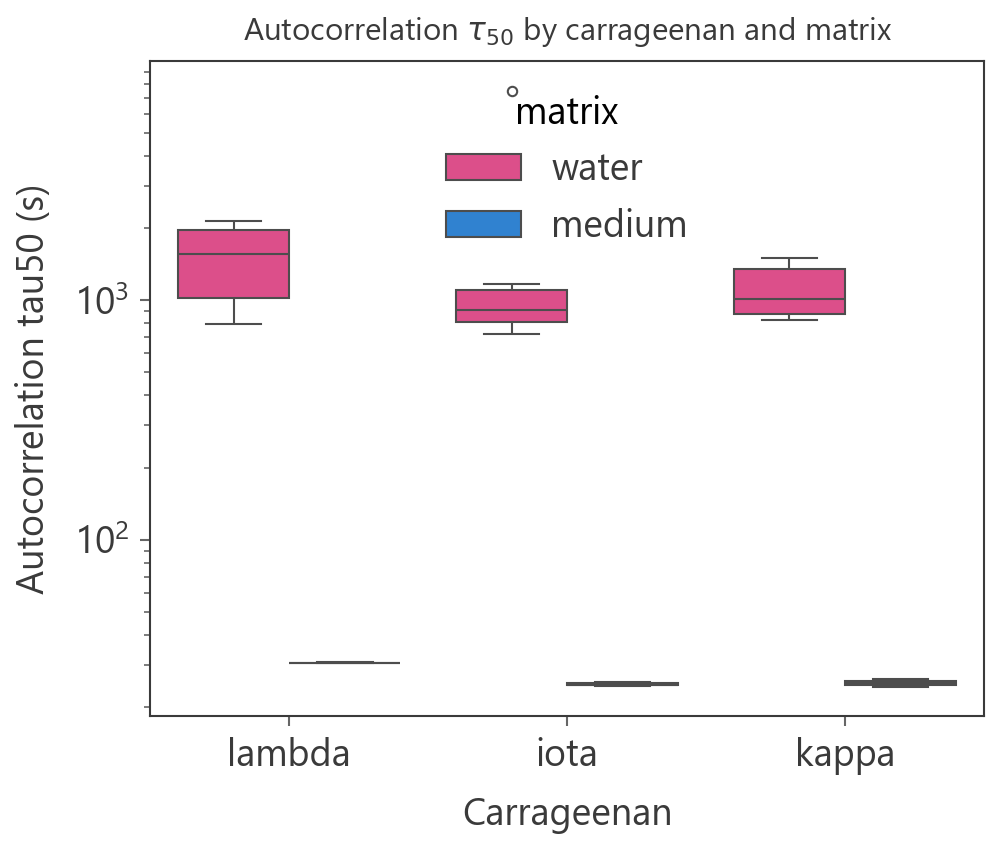

In [29]:
plt.figure(figsize=(7, 6))

plt.title("Autocorrelation $\\tau_{50}$ by carrageenan and matrix")
plt.xlabel("Carrageenan"); plt.ylabel("Autocorrelation tau50 (s)")
plt.yscale("log")

sns.boxplot(
    data=df_feat_plot,
    x="carrageenan",
    y="corr_tau50_s",
    hue="matrix"
)

plt.tight_layout()

### AUC da autocorrelação

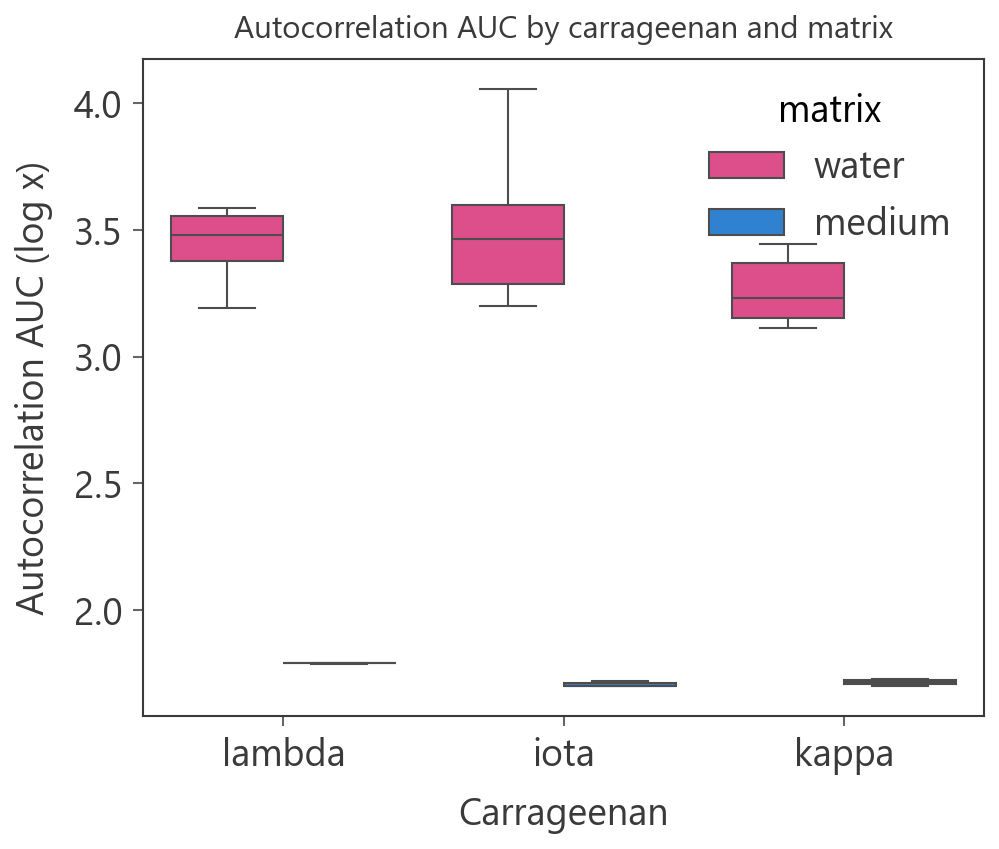

In [30]:
plt.figure(figsize=(7, 6))

plt.title("Autocorrelation AUC by carrageenan and matrix")
plt.xlabel("Carrageenan"); plt.ylabel("Autocorrelation AUC (log x)")

sns.boxplot(
    data=df_feat_plot,
    x="carrageenan",
    y="corr_auc_logx",
    hue="matrix"
)

plt.tight_layout()

### Features de distribuição

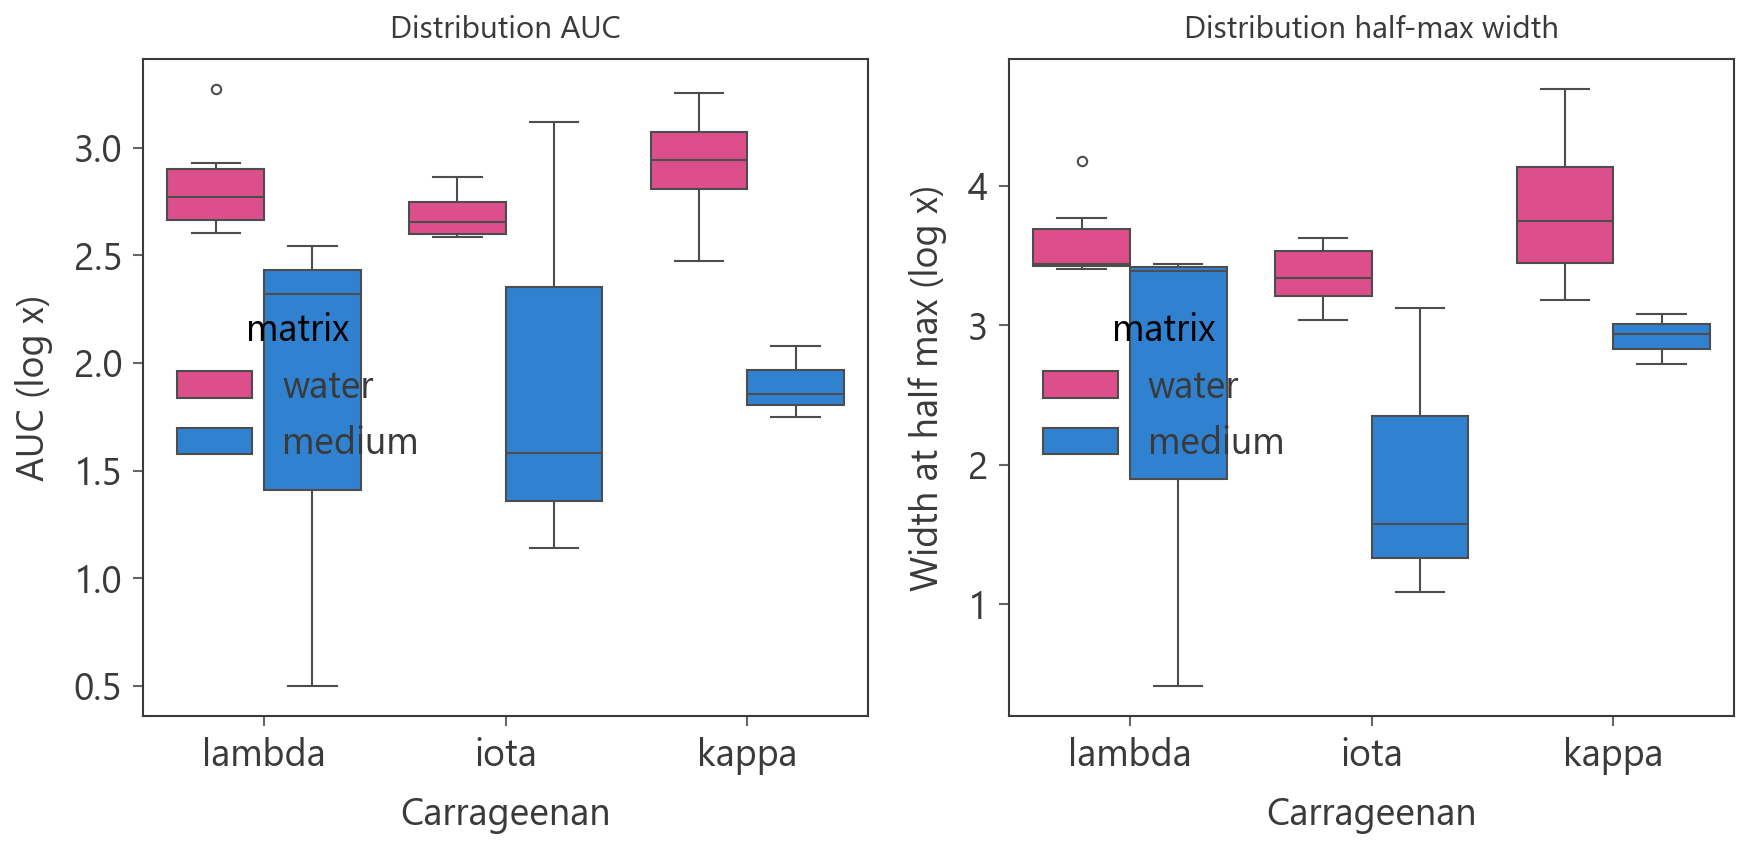

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].set_title("Distribution AUC")
axes[0].set_xlabel("Carrageenan"); axes[0].set_ylabel("AUC (log x)")

sns.boxplot(
    data=df_feat_plot,
    x="carrageenan",
    y="dist_auc_logx",
    hue="matrix",
    ax=axes[0]
)

axes[1].set_title("Distribution half-max width")
axes[1].set_xlabel("Carrageenan"); axes[1].set_ylabel("Width at half max (log x)")

sns.boxplot(
    data=df_feat_plot,
    x="carrageenan",
    y="dist_width_halfmax_logx",
    hue="matrix",
    ax=axes[1]
)

plt.tight_layout()

### Água separada por concentração

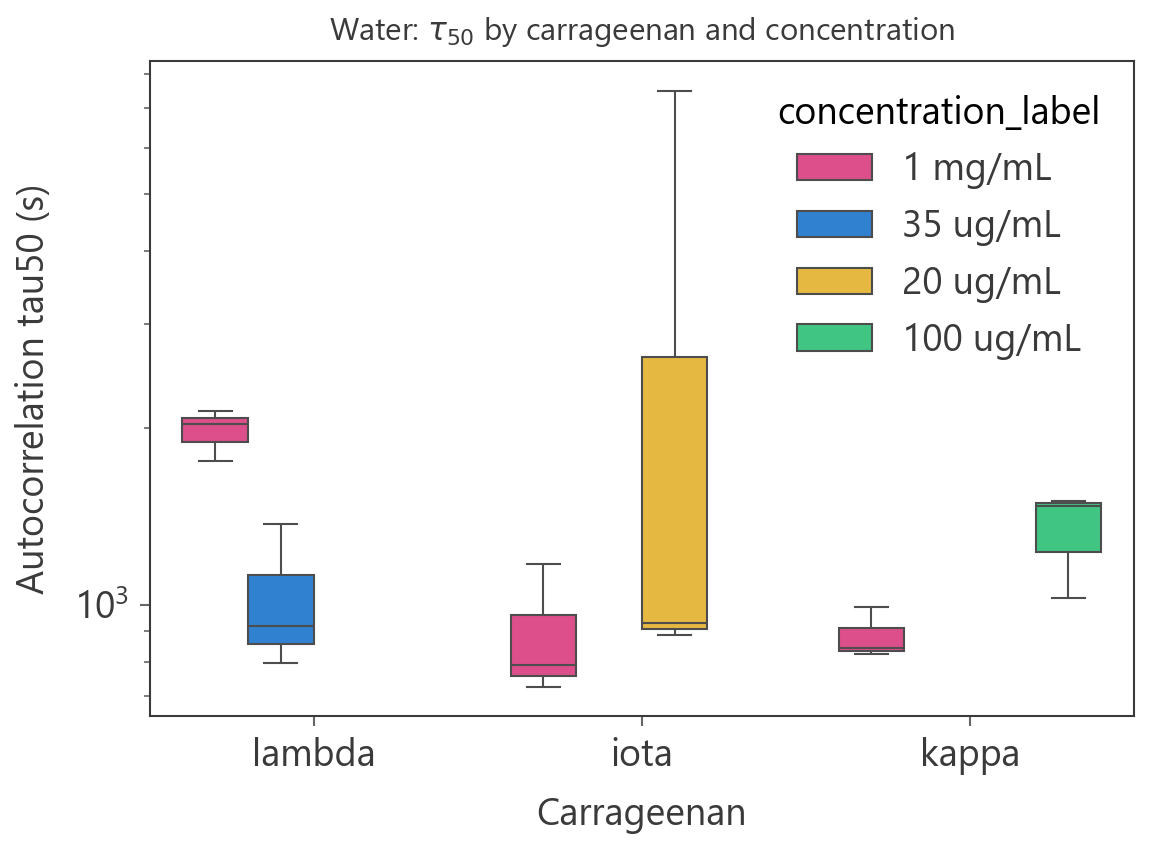

In [32]:
df_feat_water = df_feat_plot[df_feat_plot["matrix"] == "water"].copy()

plt.figure(figsize=(8, 6))

plt.title("Water: $\\tau_{50}$ by carrageenan and concentration")
plt.xlabel("Carrageenan"); plt.ylabel("Autocorrelation tau50 (s)")
plt.yscale("log")

sns.boxplot(
    data=df_feat_water,
    x="carrageenan",
    y="corr_tau50_s",
    hue="concentration_label"
)

plt.tight_layout()

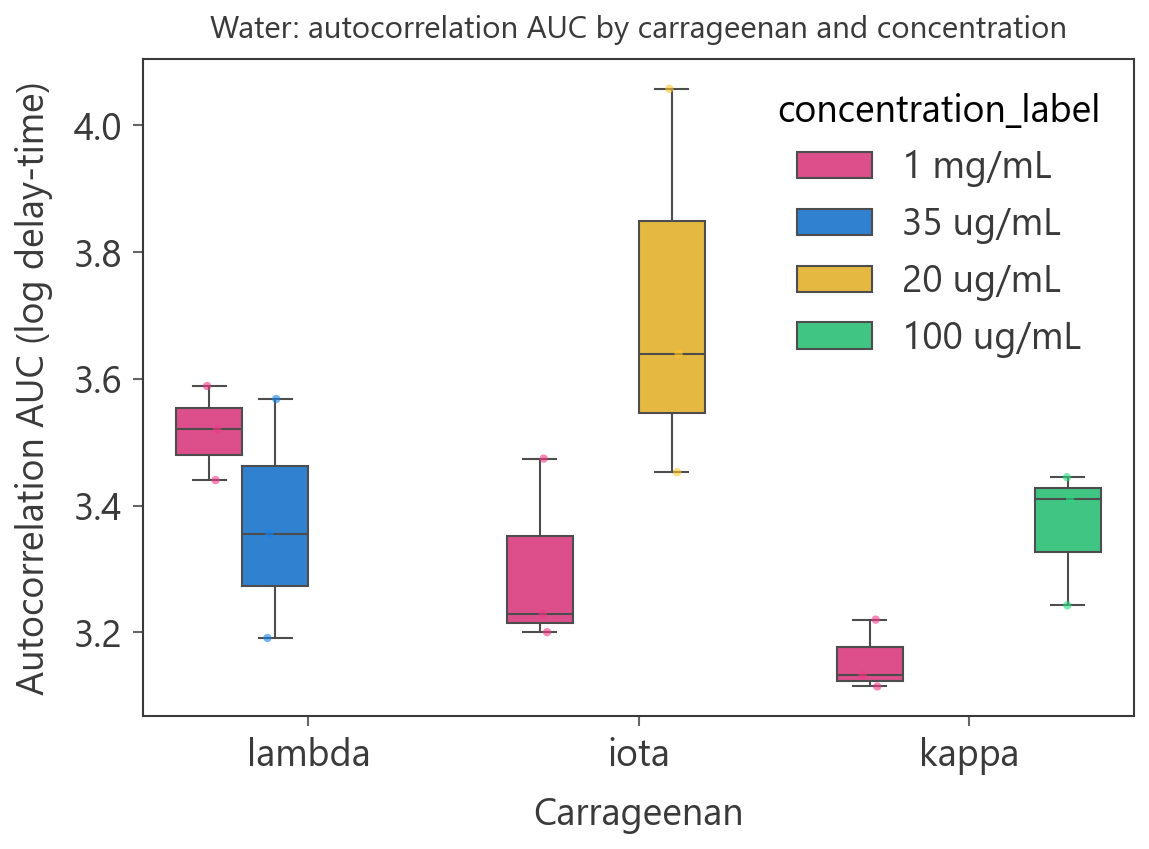

In [37]:
plt.figure(figsize=(8, 6))

plt.title("Water: autocorrelation AUC by carrageenan and concentration")

plt.xlabel("Carrageenan"); plt.ylabel("Autocorrelation AUC (log delay-time)")

sns.boxplot(
    data=df_feat_water,
    x="carrageenan",
    y="corr_auc_logx",
    hue="concentration_label"
)

sns.stripplot(
    data=df_feat_water,
    x="carrageenan",
    y="corr_auc_logx",
    hue="concentration_label",
    dodge=True,
    # color="black",
    alpha=0.6,
    size=4,
    legend=False
)

plt.tight_layout()

# Resumo interpretativo

This notebook extracted quantitative descriptors from DLS autocorrelation curves and distribution profiles.

## Autocorrelation-derived features

Autocorrelation curves were normalized independently for each measurement, allowing extraction of curve-shape descriptors such as:

- tau50: delay time at which the normalized autocorrelation decays to 50%
- tau20: delay time at which the normalized autocorrelation decays to 20%
- AUC in log-delay-time space
- initial slope in log-delay-time space

These metrics are intended to summarize the dynamic behavior of the measured systems. Higher tau values and larger AUC values indicate slower decay and are consistent with larger or more slowly diffusing hydrodynamic structures.

## Distribution-derived features

Distribution profiles were also normalized independently for each measurement. Descriptive metrics included:

- peak position along the exported distribution axis
- AUC in log-x space
- width at half maximum
- centroid position

These distribution-based features should be interpreted as descriptive profile metrics, rather than absolute physical size parameters, because the exported distribution is derived from the autocorrelation inversion and is more model-dependent.

## Interpretation strategy

For this exploratory dataset, autocorrelation-derived features should be prioritized over distribution-derived features, as they are closer to the experimental signal.

The main goal is to determine whether the qualitative observations from the exploratory curves are quantitatively supported:

1. Carrageenan systems in water should display slower autocorrelation decay and broader feature distributions.
2. Systems in biological medium should converge toward similar dynamic behavior, consistent with matrix/protein-dominated scattering.
3. Concentration-dependent differences should be evaluated primarily within the aqueous systems.

In [33]:
df_features.describe()

,replicate,corr_n_points,corr_tau50_s,corr_tau20_s,corr_auc_logx,corr_initial_slope_logx,corr_y_start,corr_y_end,dist_n_points,dist_peak_x,dist_auc_logx,dist_width_halfmax_logx,dist_centroid_x,dist_signal_raw_max,dist_signal_raw_min,Z_Average_d_nm,PdI,Mean_Count_Rate_kcps,Intercept,Quality_Factor
count,34.000000,45.0,45.000000,4.500000e+01,45.000000,45.000000,45.000000,45.0,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,34.000000,34.000000,34.000000,34.000000,34.0
mean,1.970588,192.0,1387.043809,1.051020e+05,2.908677,-0.063728,0.697938,0.0,38.590909,4.637791,2.532301,3.163395,16.006368,0.804011,0.012558,854.790294,0.565441,154.391176,0.778676,0.0
std,0.834313,0.0,2301.094523,6.164186e+05,1.016991,0.074078,0.279707,0.0,4.938309,26.051548,0.595100,0.794121,51.768640,0.199657,0.050380,863.634065,0.207986,89.690006,0.245882,0.0
min,1.000000,192.0,1.851765,6.072583e+01,1.637725,-0.180592,0.077300,0.0,10.000000,0.013300,0.496684,0.410314,0.368237,0.278000,0.000030,0.000000,0.000000,24.400000,0.000000,0.0
25%,1.000000,192.0,26.135559,7.979137e+01,1.729766,-0.142255,0.666000,0.0,39.000000,0.026300,2.435705,3.067676,2.646209,0.789750,0.000619,29.440000,0.487000,81.625000,0.686250,0.0
50%,2.000000,192.0,842.813776,2.831018e+03,3.220175,-0.020312,0.801000,0.0,40.000000,0.173000,2.710085,3.276036,3.534659,0.874500,0.001380,857.100000,0.528500,144.950000,0.886000,0.0
75%,3.000000,192.0,1373.372826,6.095791e+03,3.474247,-0.005926,0.837000,0.0,40.000000,0.404000,2.850486,3.443479,5.115114,0.913000,0.004385,1236.000000,0.623250,193.425000,0.922500,0.0
max,3.000000,192.0,9168.515537,4.144434e+06,6.347741,0.038268,1.170000,0.0,40.000000,173.000000,3.273809,4.697457,335.698836,1.050000,0.334000,3255.000000,1.000000,345.400000,1.050000,0.0
